In [25]:
import pandas as pd  # data handling
import sys  # access to system internals
import os  # filesystem utilities
sys.path.append(os.path.abspath(".."))  # allow importing project modules from parent
import scripts.plot_utils as plot_utils  # helper to save plots automatically
import seaborn as sns  # plotting helper
import matplotlib.pyplot as plt  # matplotlib interface
import math

In [ ]:
mat = pd.read_csv("../data/processed/processed_mat.csv" , encoding="utf-8") # load raw math data
por = pd.read_csv("../data/processed/processed_por.csv" , encoding="utf-8") # load raw Portuguese data

In [ ]:
mat.head() # preview first rows of math dataset

,sex_M,address_U,famsize_LE3,Pstatus_T,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.062194,-0.236010,0.801479,-0.540699,-1.003789,-0.399289,0.036424,-1.782467,-1.254791,-0.964934
1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.178860,-0.236010,-0.097908,-0.540699,-1.003789,-0.399289,-0.213796,-1.782467,-1.520979,-0.964934
2,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0.062194,-0.236010,-0.997295,0.583385,0.551100,-0.399289,0.536865,-1.179147,-0.722415,-0.090739
3,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,-1.054472,-1.238419,-0.997295,-0.540699,-1.003789,1.041070,-0.464016,1.234133,0.874715,1.002004
4,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,...,0.062194,-0.236010,-0.997295,-0.540699,-0.226345,1.041070,-0.213796,-1.480807,-0.190038,-0.090739


In [ ]:
mat.info() # schema/nonnull counts for math dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 47 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sex_M              395 non-null    float64
 1   address_U          395 non-null    float64
 2   famsize_LE3        395 non-null    float64
 3   Pstatus_T          395 non-null    float64
 4   schoolsup_yes      395 non-null    float64
 5   famsup_yes         395 non-null    float64
 6   paid_yes           395 non-null    float64
 7   activities_yes     395 non-null    float64
 8   nursery_yes        395 non-null    float64
 9   higher_yes         395 non-null    float64
 10  internet_yes       395 non-null    float64
 11  romantic_yes       395 non-null    float64
 12  school_GP          395 non-null    float64
 13  school_MS          395 non-null    float64
 14  Mjob_at_home       395 non-null    float64
 15  Mjob_health        395 non-null    float64
 16  Mjob_other         395 non

In [ ]:
mat.isnull().sum()  # missing values per column (math)

sex_M                0
address_U            0
famsize_LE3          0
Pstatus_T            0
schoolsup_yes        0
famsup_yes           0
paid_yes             0
activities_yes       0
nursery_yes          0
higher_yes           0
internet_yes         0
romantic_yes         0
school_GP            0
school_MS            0
Mjob_at_home         0
Mjob_health          0
Mjob_other           0
Mjob_services        0
Mjob_teacher         0
Fjob_at_home         0
Fjob_health          0
Fjob_other           0
Fjob_services        0
Fjob_teacher         0
reason_course        0
reason_home          0
reason_other         0
reason_reputation    0
guardian_father      0
guardian_mother      0
guardian_other       0
age                  0
Medu                 0
Fedu                 0
traveltime           0
studytime            0
failures             0
famrel               0
freetime             0
goout                0
Dalc                 0
Walc                 0
health               0
absences   

In [12]:
numeric_df = mat.select_dtypes(include=["int64", "float64"])  # numeric subset (math)

Q1 = numeric_df.quantile(0.25)  # first quartile
Q3 = numeric_df.quantile(0.75)  # third quartile
IQR = Q3 - Q1  # interquartile range

outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))  # Tukey rule for outliers
outliers.sum().sort_values(ascending=False)  # count outliers per feature

guardian_father      90
address_U            88
failures             83
nursery_yes          81
internet_yes         66
Mjob_at_home         59
Mjob_teacher         58
schoolsup_yes        51
school_GP            46
school_MS            46
Pstatus_T            41
reason_other         36
Mjob_health          34
guardian_other       32
Fjob_teacher         29
studytime            27
famrel               26
higher_yes           20
Fjob_at_home         20
freetime             19
Dalc                 18
Fjob_health          18
absences             15
G2                   13
traveltime            8
Fedu                  2
age                   2
goout                 0
Medu                  0
Walc                  0
health                0
G1                    0
sex_M                 0
guardian_mother       0
reason_reputation     0
reason_home           0
reason_course         0
Fjob_services         0
Fjob_other            0
Mjob_services         0
Mjob_other            0
romantic_yes    

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


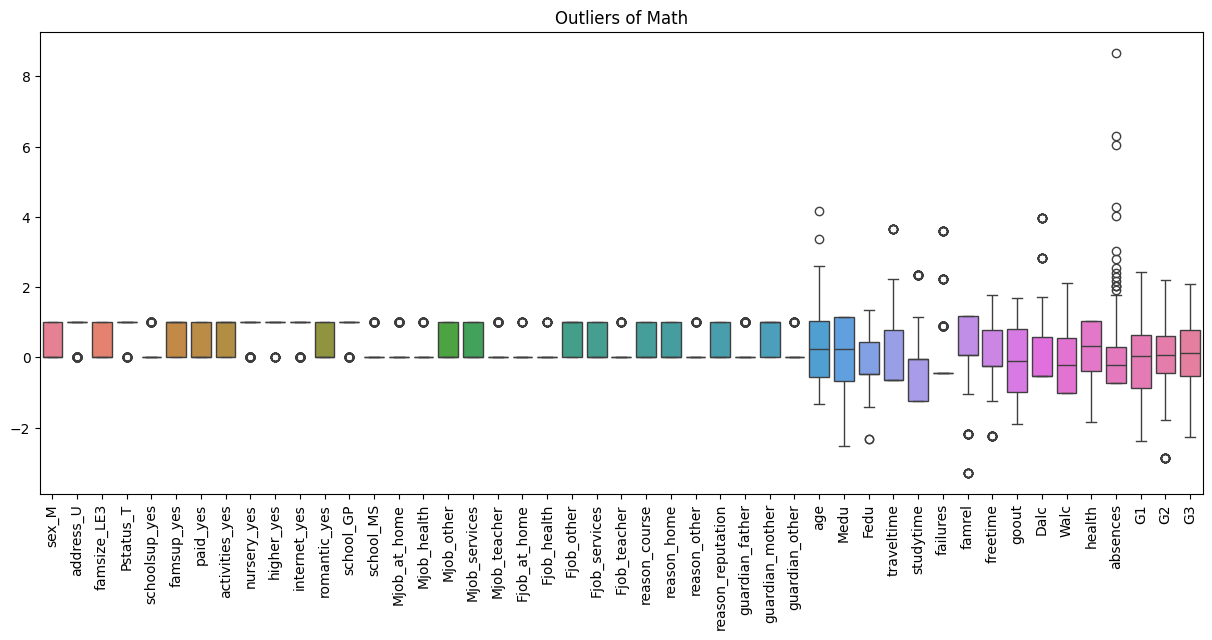

In [14]:
plt.figure(figsize=(15, 6))  # new figure for boxplot
sns.boxplot(data=numeric_df)  # boxplots of numeric math features
plt.xticks(rotation=90)  # rotate x labels
plt.title("Outliers of Math")  # title
plot_utils.save_all_figs("Outliers of Math" , "Processed")  # save plot image
plt.show()  # display plot

In [15]:
por.head()  # preview first rows of Portuguese dataset

,sex_M,address_U,famsize_LE3,Pstatus_T,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.062194,-0.236010,0.801479,-0.540699,-1.003789,-0.399289,-0.213796,-3.290767,0.076150,0.127809
1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.178860,-0.236010,-0.097908,-0.540699,-1.003789,-0.399289,-0.464016,-0.575827,0.076150,0.127809
2,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.062194,-0.236010,-0.997295,0.583385,0.551100,-0.399289,0.036424,0.329153,0.608526,0.346358
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,...,-1.054472,-1.238419,-0.997295,-0.540699,-1.003789,1.041070,-0.714236,0.932473,0.874715,0.783456
4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.062194,-0.236010,-0.997295,-0.540699,-0.226345,1.041070,-0.714236,0.027493,0.608526,0.564907


In [16]:
por.info()  # schema/nonnull counts for Portuguese dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 47 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sex_M              649 non-null    float64
 1   address_U          649 non-null    float64
 2   famsize_LE3        649 non-null    float64
 3   Pstatus_T          649 non-null    float64
 4   schoolsup_yes      649 non-null    float64
 5   famsup_yes         649 non-null    float64
 6   paid_yes           649 non-null    float64
 7   activities_yes     649 non-null    float64
 8   nursery_yes        649 non-null    float64
 9   higher_yes         649 non-null    float64
 10  internet_yes       649 non-null    float64
 11  romantic_yes       649 non-null    float64
 12  school_GP          649 non-null    float64
 13  school_MS          649 non-null    float64
 14  Mjob_at_home       649 non-null    float64
 15  Mjob_health        649 non-null    float64
 16  Mjob_other         649 non

In [17]:
por.isnull().sum()  # missing values per column (Portuguese)

sex_M                0
address_U            0
famsize_LE3          0
Pstatus_T            0
schoolsup_yes        0
famsup_yes           0
paid_yes             0
activities_yes       0
nursery_yes          0
higher_yes           0
internet_yes         0
romantic_yes         0
school_GP            0
school_MS            0
Mjob_at_home         0
Mjob_health          0
Mjob_other           0
Mjob_services        0
Mjob_teacher         0
Fjob_at_home         0
Fjob_health          0
Fjob_other           0
Fjob_services        0
Fjob_teacher         0
reason_course        0
reason_home          0
reason_other         0
reason_reputation    0
guardian_father      0
guardian_mother      0
guardian_other       0
age                  0
Medu                 0
Fedu                 0
traveltime           0
studytime            0
failures             0
famrel               0
freetime             0
goout                0
Dalc                 0
Walc                 0
health               0
absences   

In [18]:
numeric_df2 = por.select_dtypes(include=["int64", "float64"])  # numeric subset (Portuguese)

Q1 = numeric_df2.quantile(0.25)  # first quartile
Q3 = numeric_df2.quantile(0.75)  # third quartile
IQR = Q3 - Q1  # interquartile range

outliers = (numeric_df2 < (Q1 - 1.5 * IQR)) | (numeric_df2 > (Q3 + 1.5 * IQR))  # Tukey rule for outliers
outliers.sum().sort_values(ascending=False)  # count outliers per feature

guardian_father      153
internet_yes         151
reason_home          149
reason_reputation    143
Mjob_services        136
Mjob_at_home         135
nursery_yes          128
failures             100
Pstatus_T             80
reason_other          72
Mjob_teacher          72
higher_yes            69
schoolsup_yes         68
famrel                51
Mjob_health           48
freetime              45
Fjob_at_home          42
guardian_other        41
paid_yes              39
Fjob_teacher          36
studytime             35
Dalc                  34
G2                    25
absences              23
Fjob_health           23
traveltime            16
G1                    16
G3                    16
age                    3
reason_course          0
school_GP              0
famsize_LE3            0
famsup_yes             0
activities_yes         0
health                 0
Walc                   0
romantic_yes           0
goout                  0
school_MS              0
guardian_mother        0


All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


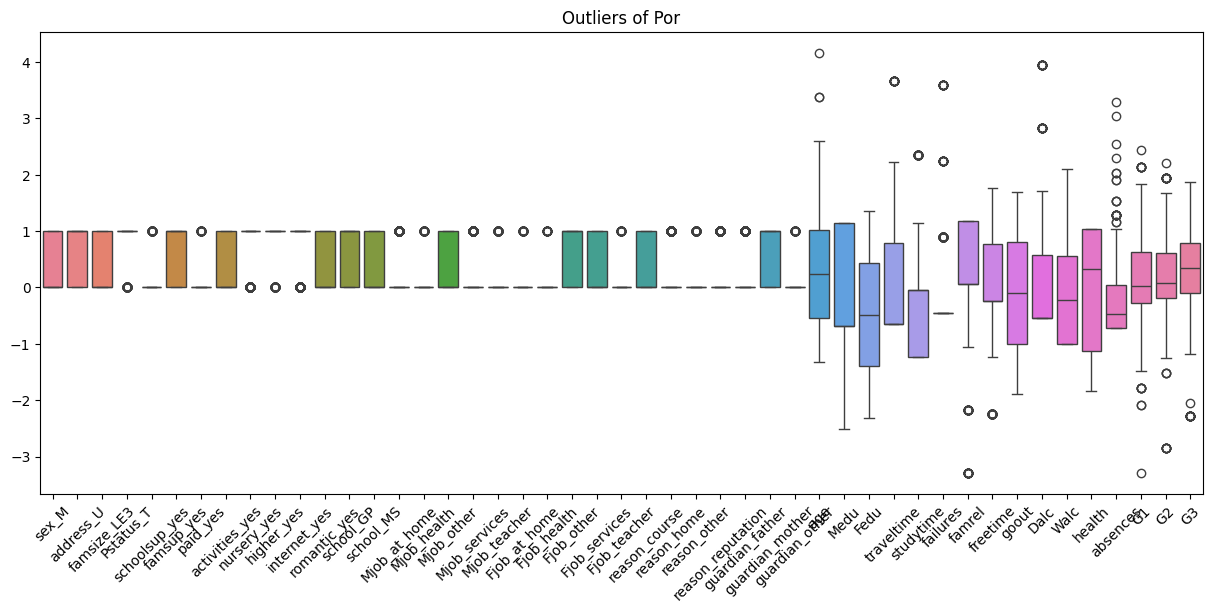

In [19]:
plt.figure(figsize=(15, 6))  # new figure for boxplot
sns.boxplot(data=numeric_df2)  # boxplots of numeric Portuguese features
plt.xticks(rotation=45)  # rotate x labels
plt.title("Outliers of Por")  # title
plot_utils.save_all_figs("Outliers of Por" , "Processed")  # save plot image
plt.show()  # display plot

In [20]:
num_cols_mat = mat.select_dtypes(include=["int64", "float64"]).columns  # numeric columns in math data
num_cols_por = por.select_dtypes(include=["int64", "float64"]).columns  # numeric columns in Portuguese data

In [23]:
def plot_distributions(df, title):  # plot grid of distributions with KDE
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns  # numeric columns
    n = len(numeric_cols)  # number of plots
    cols_per_row = 4  # grid width
    rows = math.ceil(n / cols_per_row)  # rows needed
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3.5))  # subplot grid
    axes = axes.flatten()  # flatten axes array
    palette = sns.color_palette("crest", n)  # color palette
    for i, col in enumerate(numeric_cols):  # iterate columns
        sns.histplot(df[col], bins=20, kde=True, ax=axes[i], color=palette[i])  # hist + KDE
        axes[i].set_title(col, fontsize=10)  # title per plot
        axes[i].set_xlabel("")  # remove x label text
    for ax in axes[n:]:  # extra axes
        ax.remove()  # drop unused axes
    fig.suptitle(title, fontsize=16, y=1.02)  # overall title
    fig.tight_layout()  # adjust layout
    plot_utils.save_all_figs(title , "Processed")
    plt.show()  # display plots

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


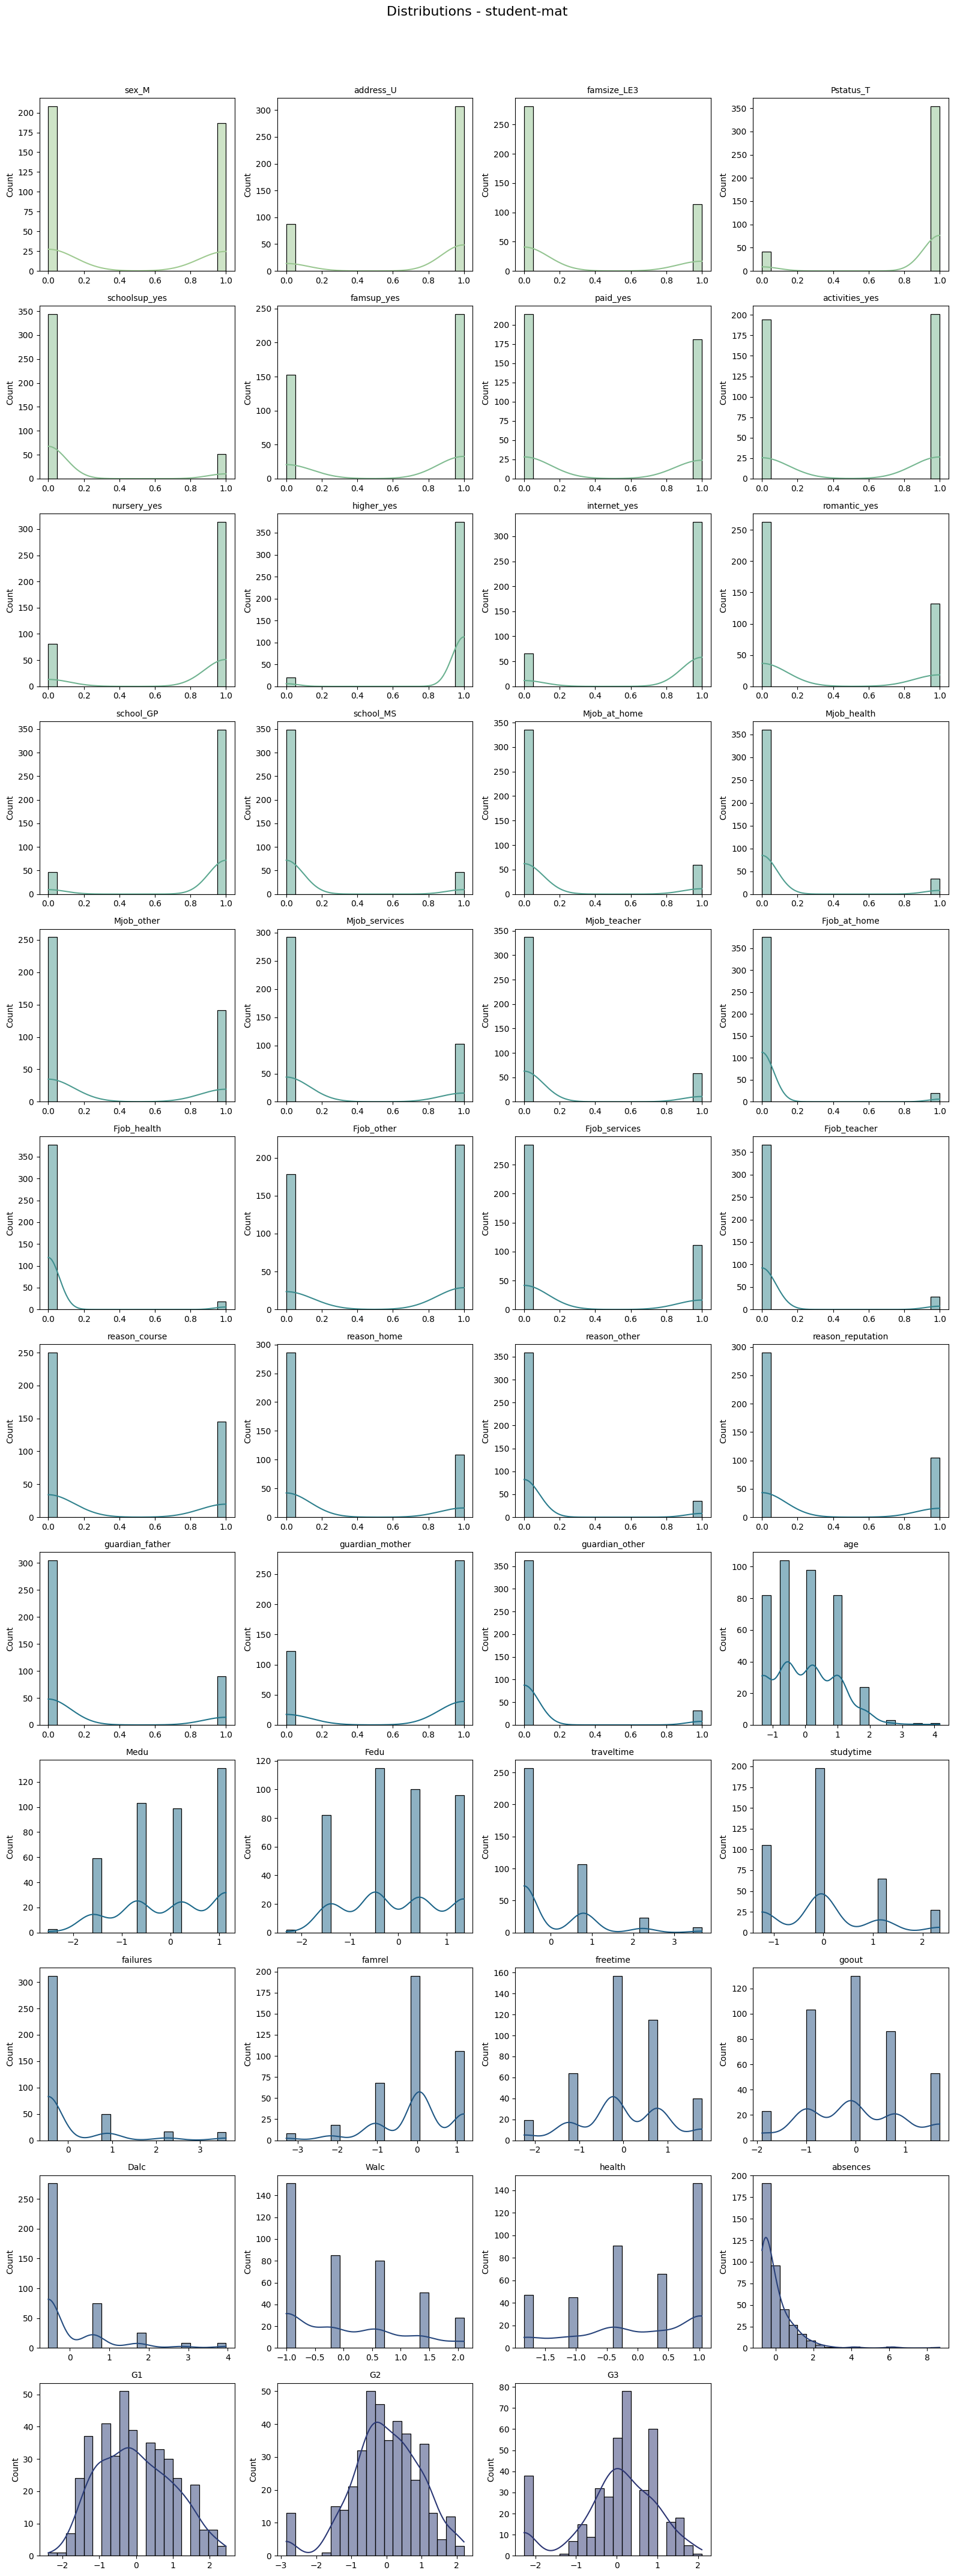

In [26]:
plot_distributions(mat, "Distributions - student-mat")  # distributions for math dataset

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


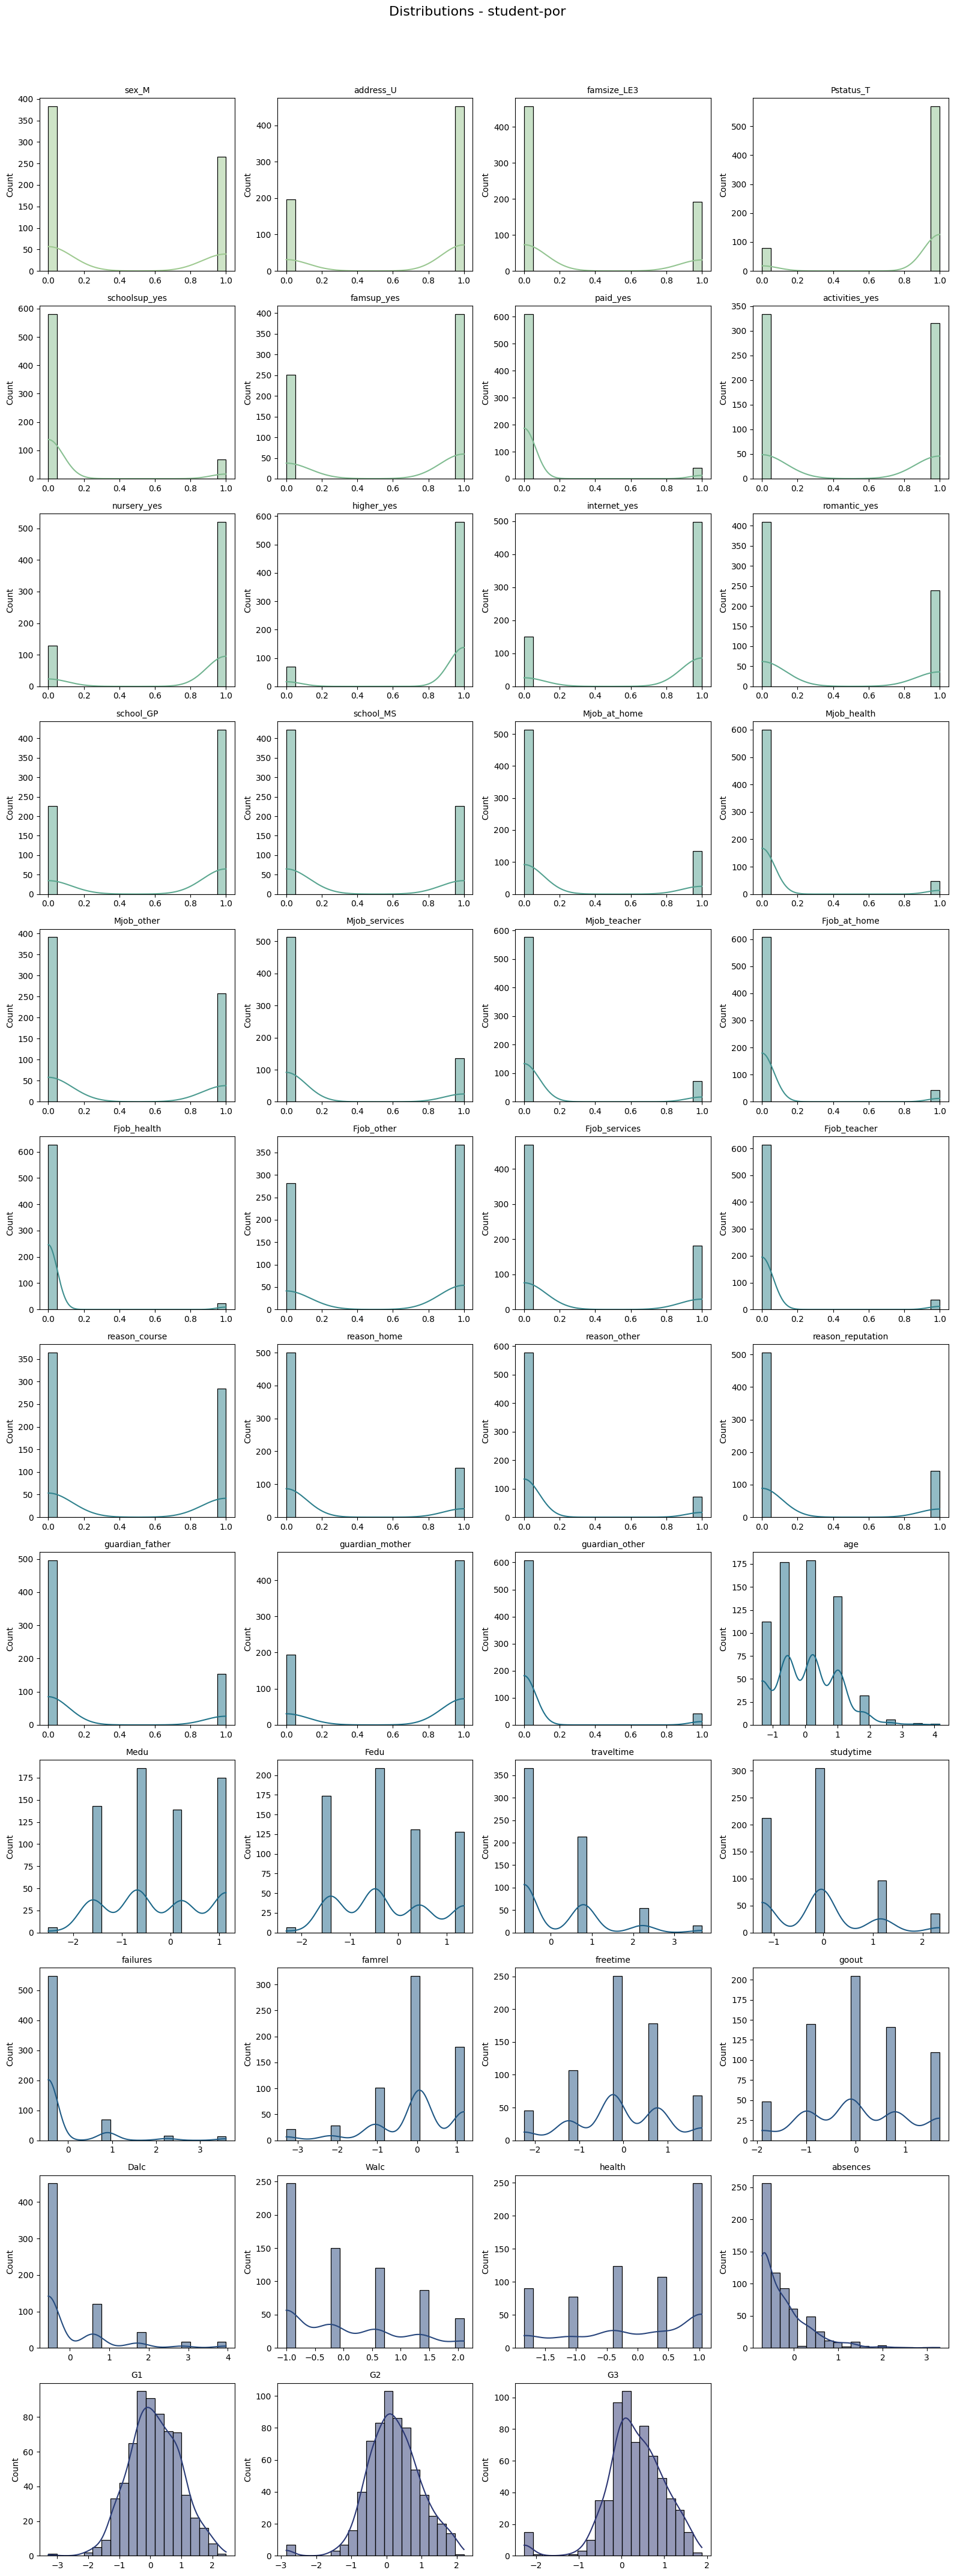

In [27]:
plot_distributions(por, "Distributions - student-por")  # distributions for Portuguese dataset

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


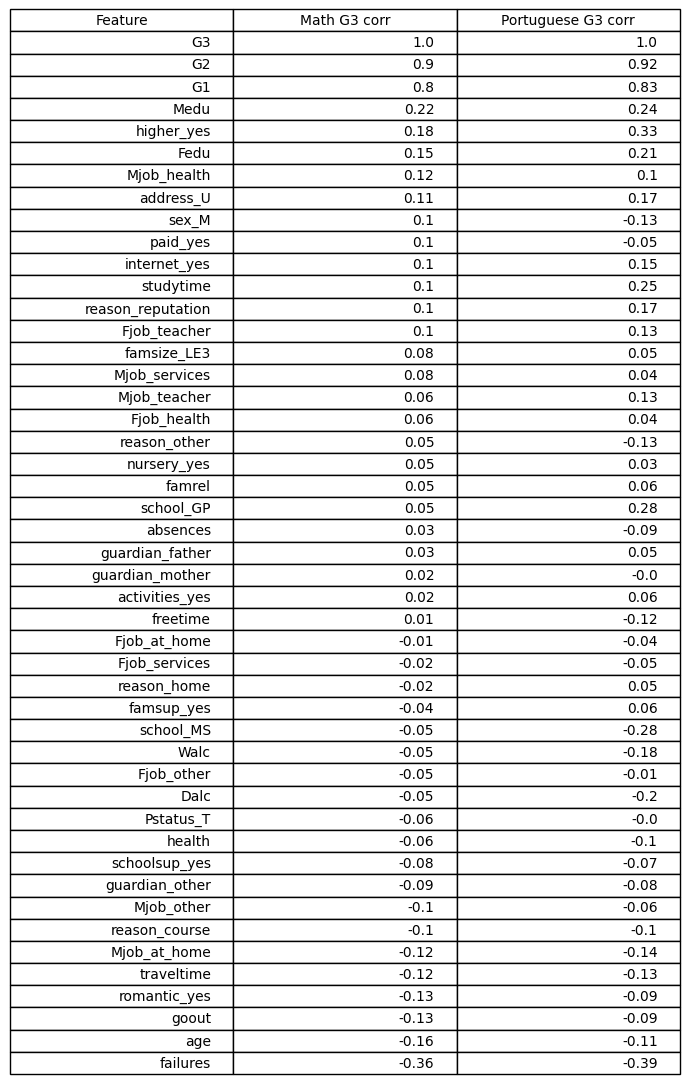

In [32]:
corr_mat = mat[num_cols_mat].corr()['G3'].sort_values(ascending=False)  # correlations vs G3 (math)
corr_por = por[num_cols_por].corr()['G3'].sort_values(ascending=False)  # correlations vs G3 (Portuguese)

corr_table = pd.concat([corr_mat, corr_por], axis=1)  # combine series
corr_table.columns = ['Math G3 corr', 'Portuguese G3 corr']  # label columns
corr_table = corr_table.round(2)  # round values

fig, ax = plt.subplots(figsize=(7, 0.2 * len(corr_table) + 1.5))  # table figure
ax.axis('off')  # hide axes
ax.axis('tight')  # tight layout
table = ax.table(
    cellText=corr_table.reset_index().values,  # table data
    colLabels=['Feature', 'Math G3 corr', 'Portuguese G3 corr'],  # headers
    loc='center',  # center table
)
table.auto_set_font_size(False)  # control font size
table.set_fontsize(10)  # set font size
table.scale(1, 1.3)  # scale table
fig.tight_layout()  # adjust layout
plot_utils.save_all_figs("Corr of features with G3 in mat and por file" , "Processed")
plt.show()  # display table

In [33]:
corr_mat_full = mat[num_cols_mat].corr()  # full correlation matrix (math)
corr_por_full = por[num_cols_por].corr()  # full correlation matrix (Portuguese)

In [34]:
def plot_corr_heatmap(corr_df, title):  # plot full correlation heatmap
    n = len(corr_df.columns)  # number of features
    plt.figure(figsize=(0.5 * n + 6, 0.5 * n + 6))  # size based on features
    sns.heatmap(
        corr_df,  # correlation matrix
        annot=True,  # show values
        fmt=".2f",  # format values
        cmap="RdBu_r",  # diverging cmap
        center=0,  # center at zero
        linewidths=0.3,  # grid lines
        square=True,  # square cells
        cbar_kws={"shrink": 0.6},  # colorbar size
    )
    plt.xticks(rotation=45, ha="right")  # rotate x labels
    plt.yticks(rotation=0)  # y labels orientation
    plt.title(title)  # plot title
    plot_utils.save_all_figs(title , "Processed")
    plt.tight_layout()  # layout

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


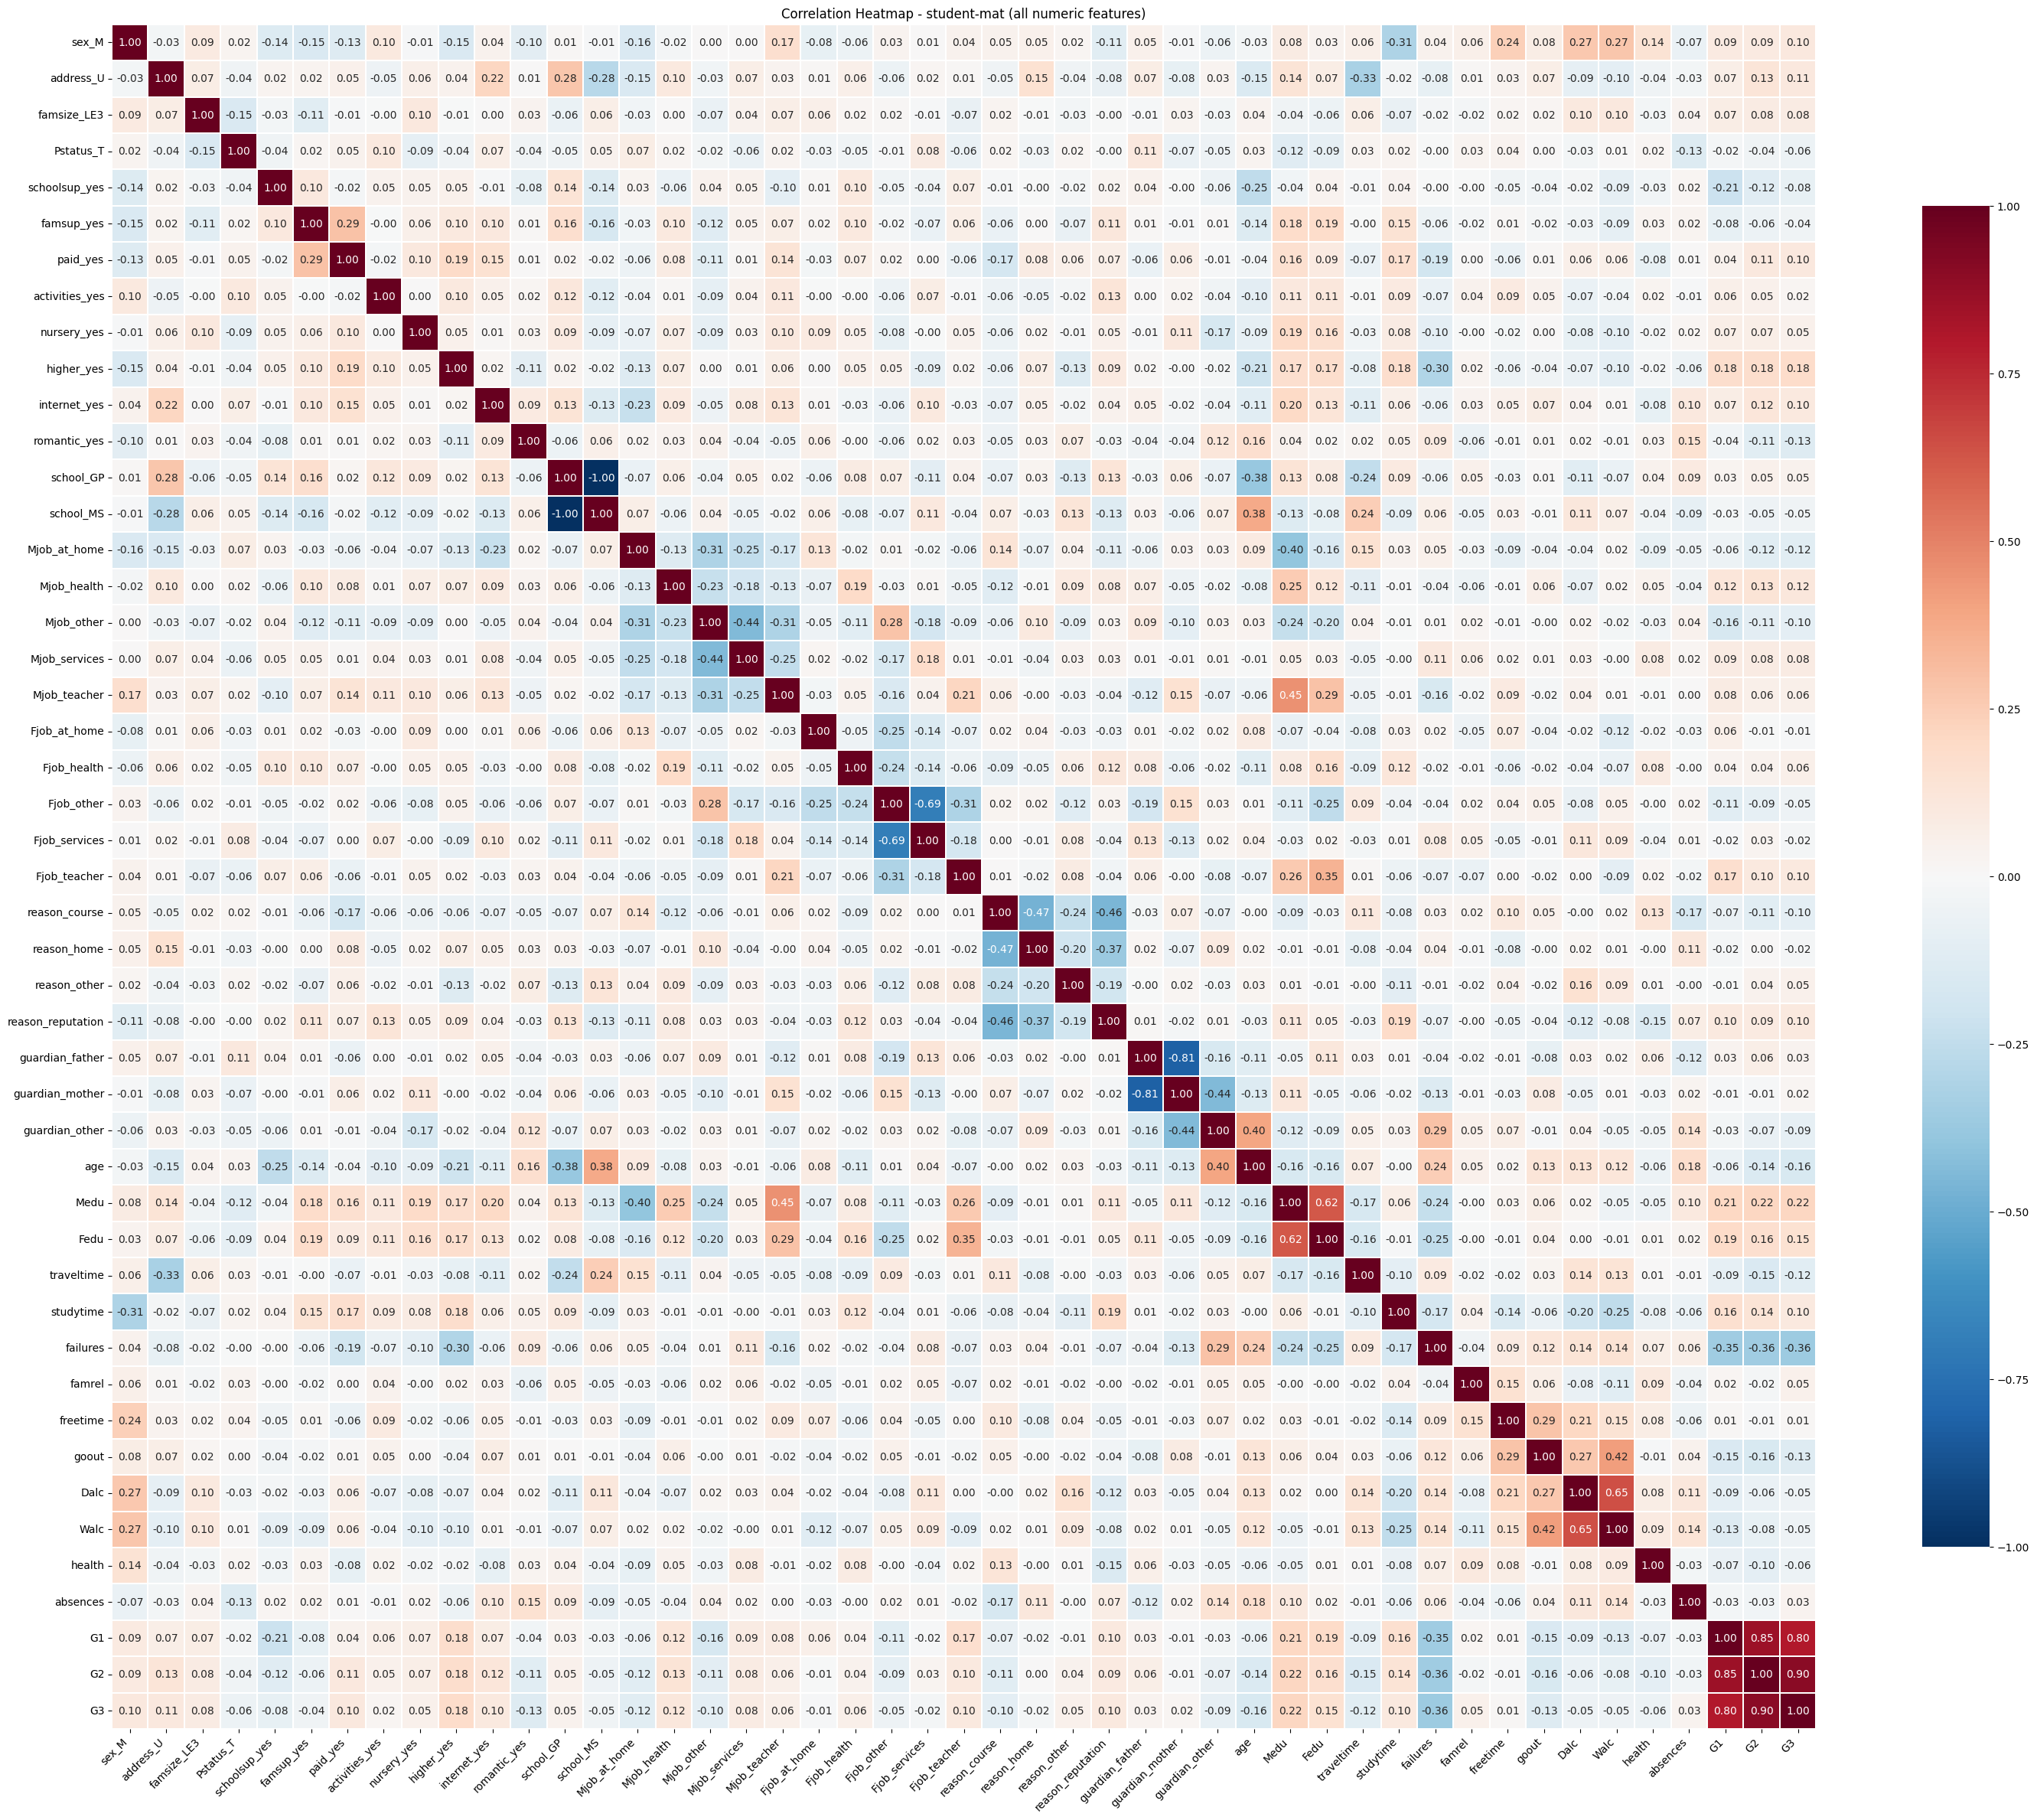

In [35]:
plot_corr_heatmap(corr_mat_full, 'Correlation Heatmap - student-mat (all numeric features)')  # heatmap for math

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


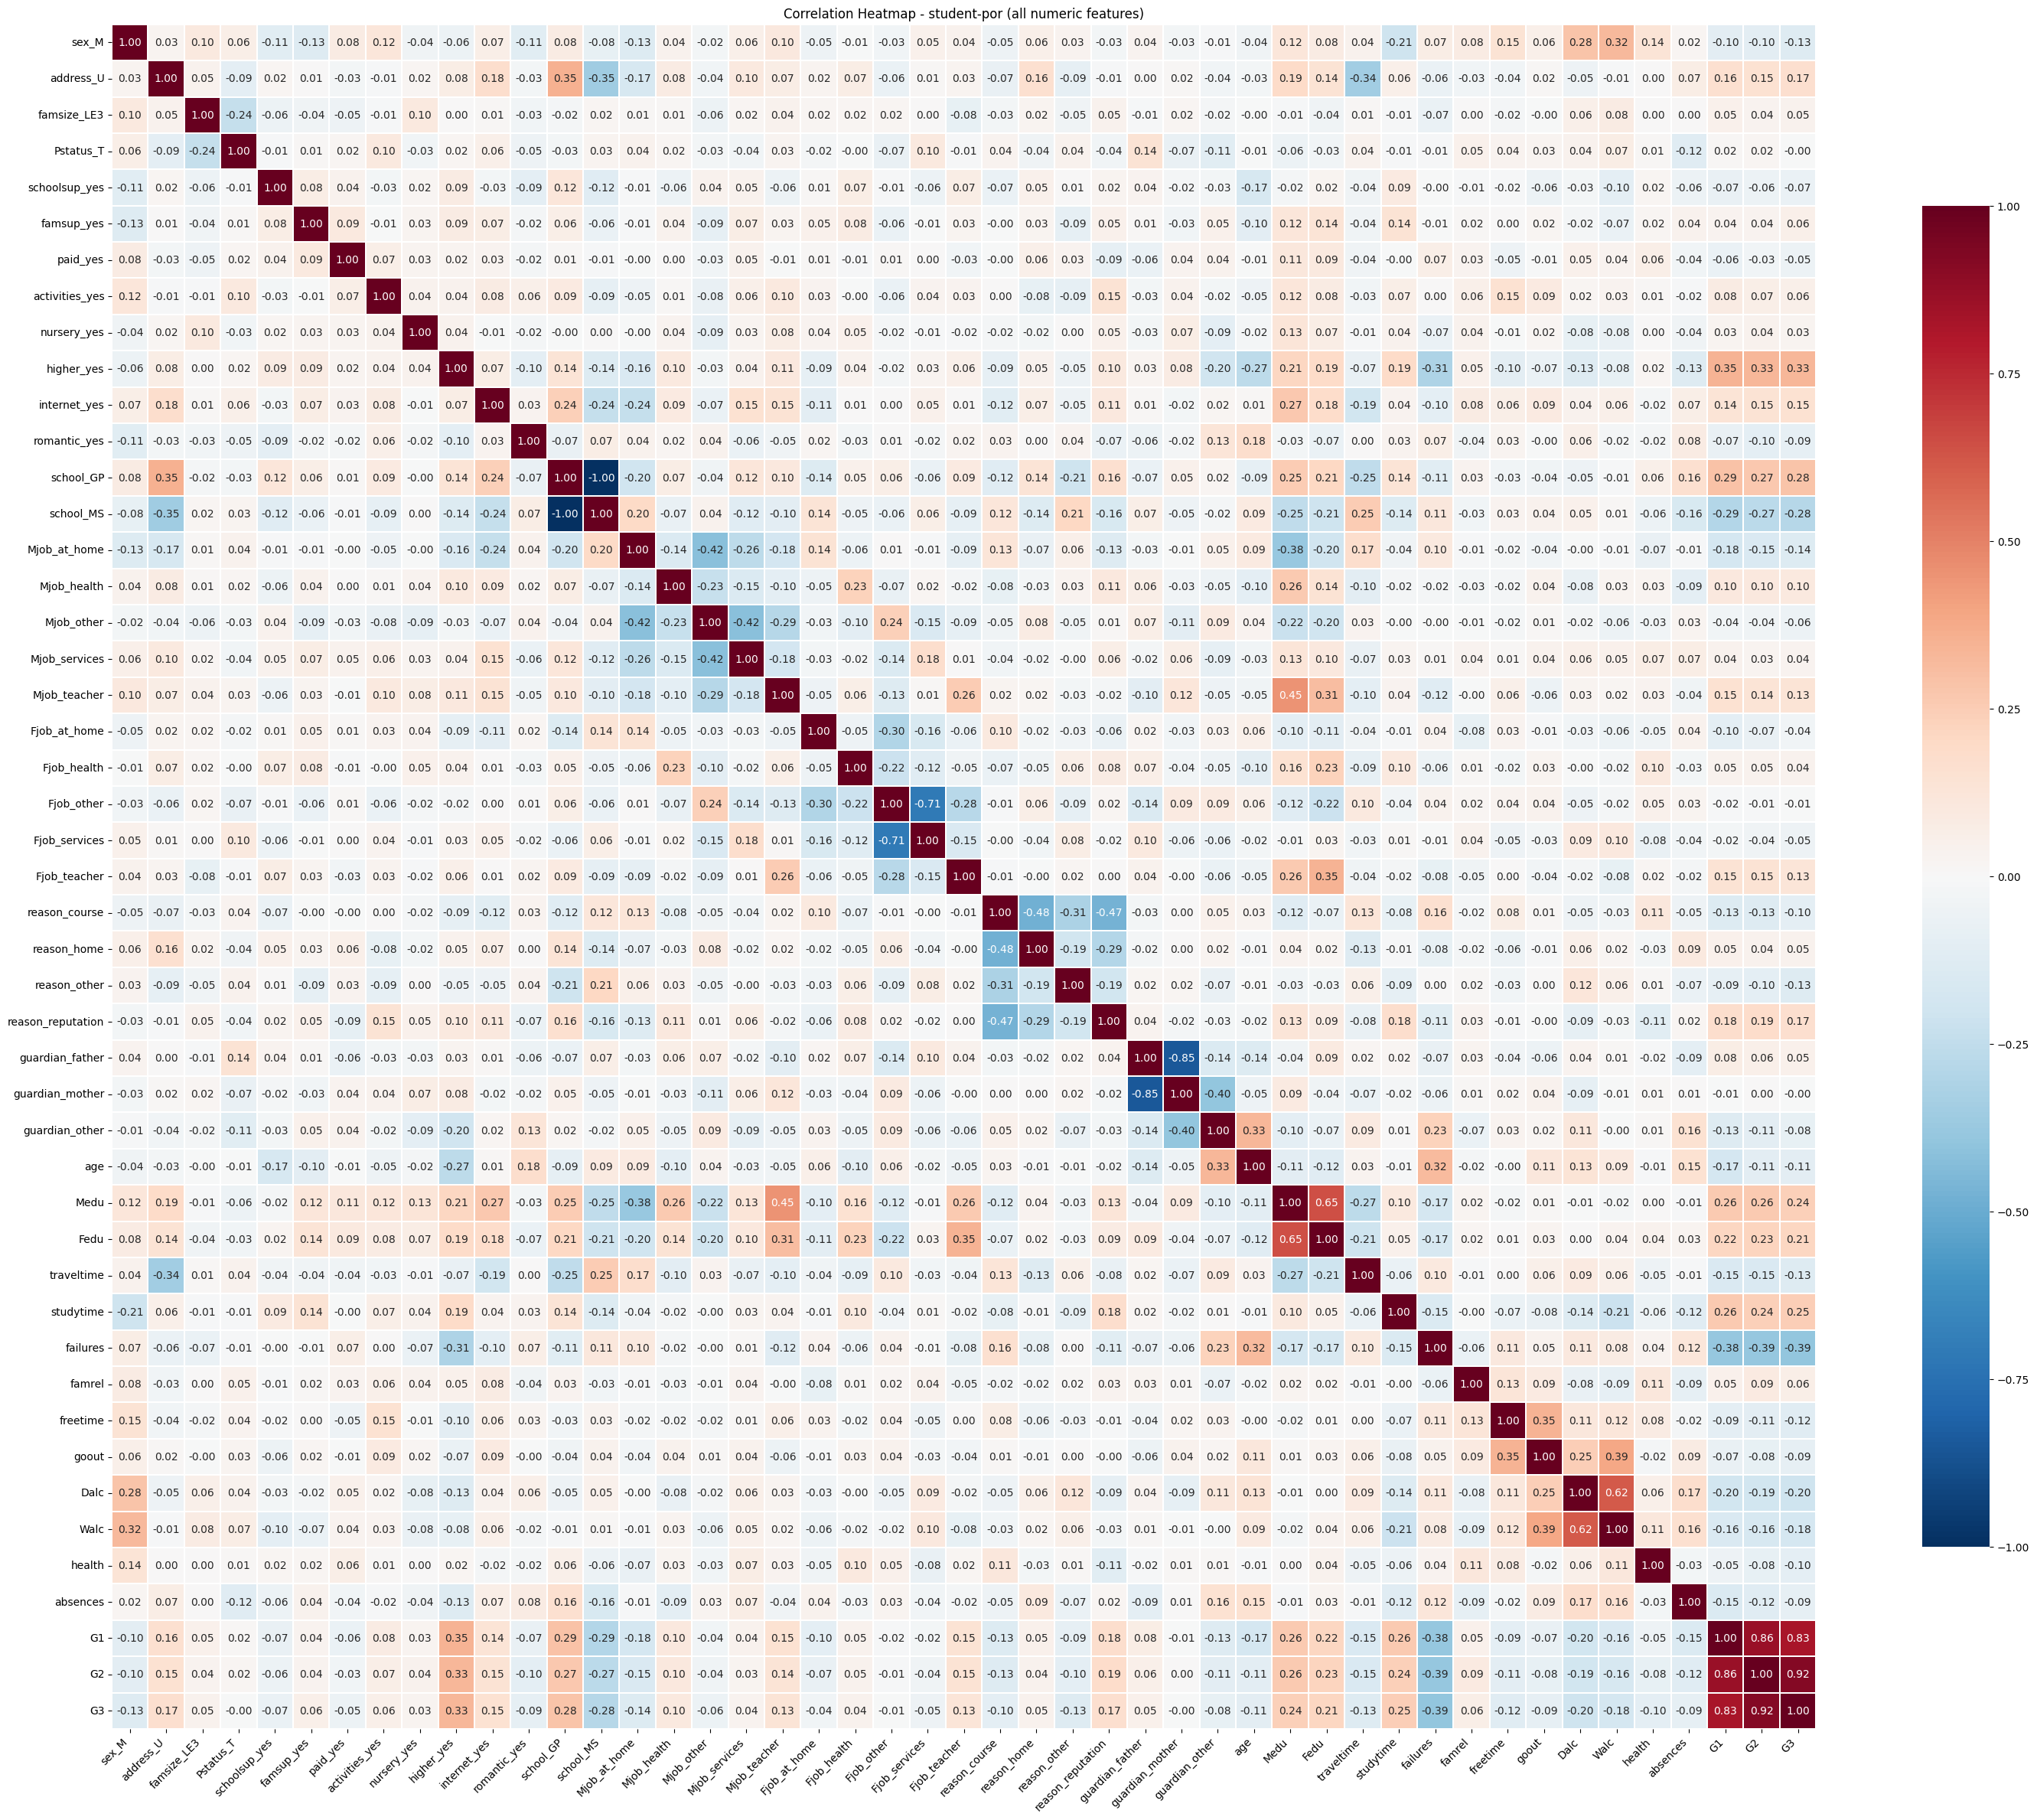

In [36]:
plot_corr_heatmap(corr_por_full, 'Correlation Heatmap - student-por (all numeric features)')  # heatmap for Portuguese

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


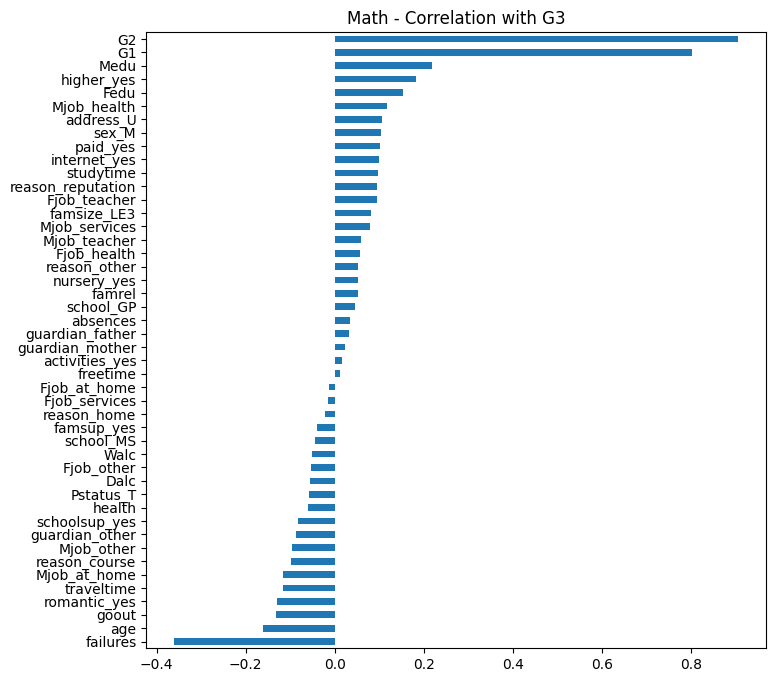

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


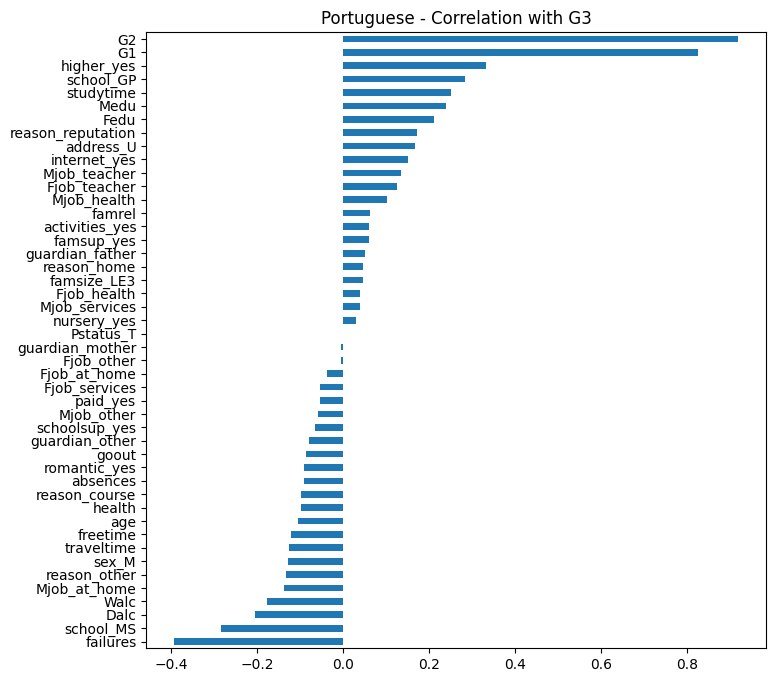

In [37]:
# Correlation with G3
mat_G3_corr = corr_mat_full["G3"].sort_values(ascending=False)  # math correlations sorted
por_G3_corr = corr_por_full["G3"].sort_values(ascending=False)  # Portuguese correlations sorted

plt.figure(figsize=(7,5))  # bar plot figure (math)
mat_G3_corr.drop("G3").sort_values().plot(kind="barh", figsize=(8,8), title="Math - Correlation with G3")  # barh for math
plot_utils.save_all_figs("Math - Correlation with G3" , "Processed")  # save figures
plt.show()  # display

plt.figure(figsize=(7,5))  # bar plot figure (Portuguese)
por_G3_corr.drop("G3").sort_values().plot(kind="barh", figsize=(8,8), title="Portuguese - Correlation with G3")  # barh for Portuguese
plot_utils.save_all_figs("Portuguese - Correlation with G3" , "Processed")  # save figures
plt.show()  # display

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


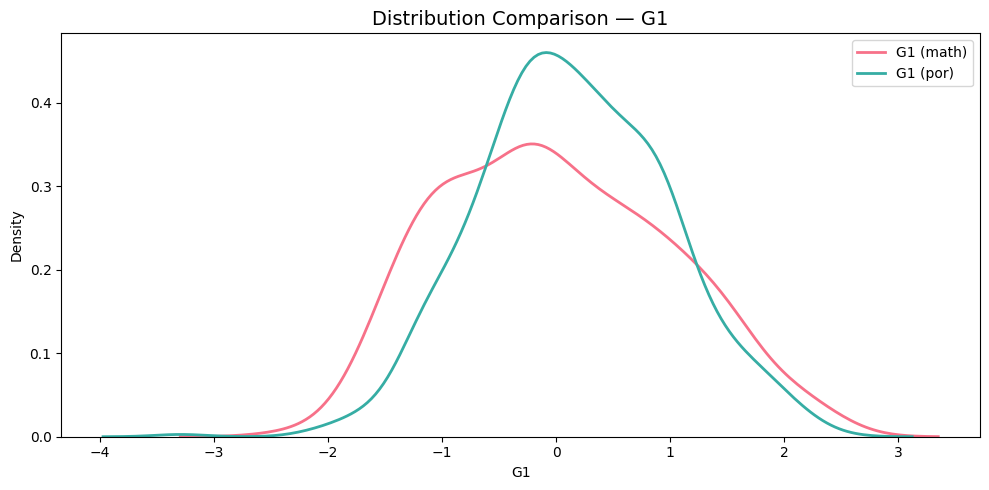

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


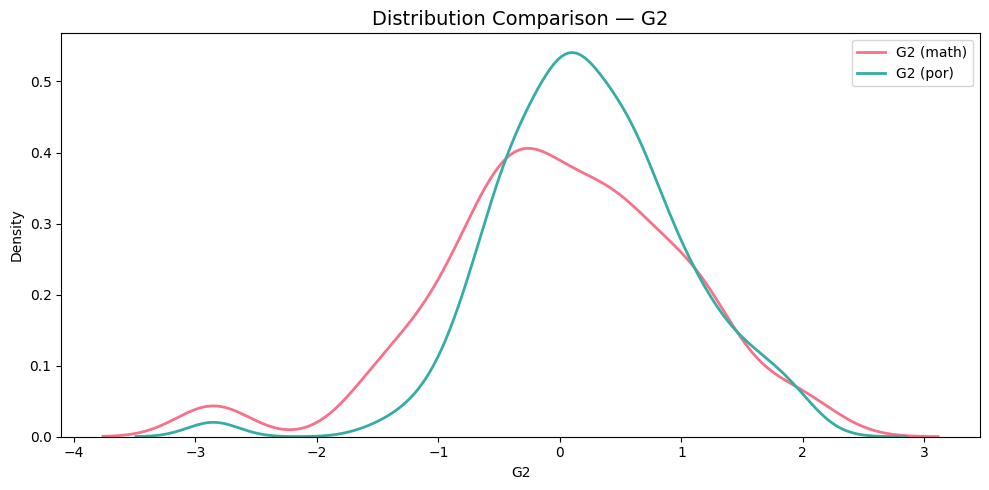

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


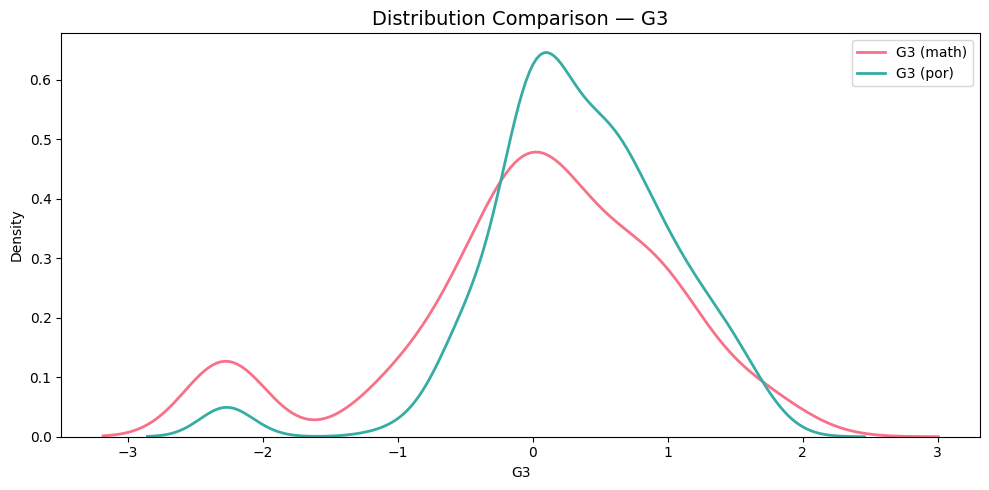

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


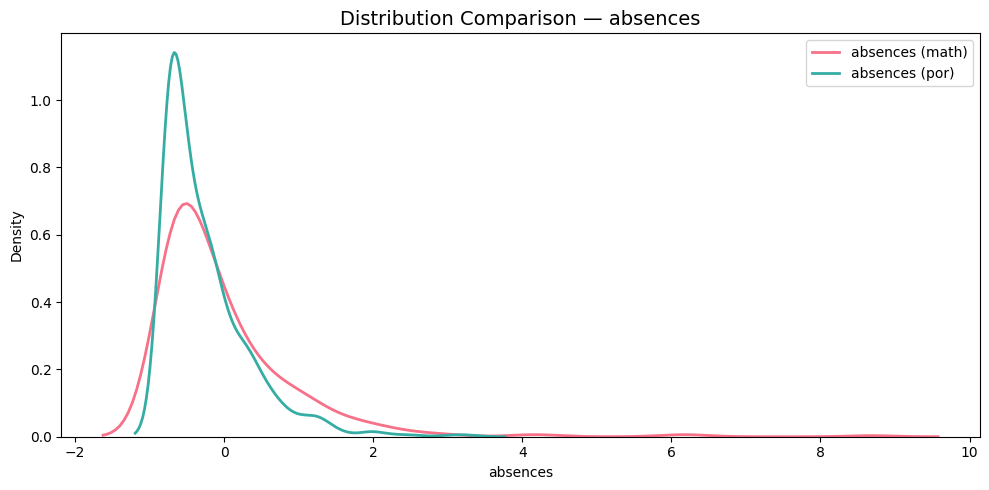

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


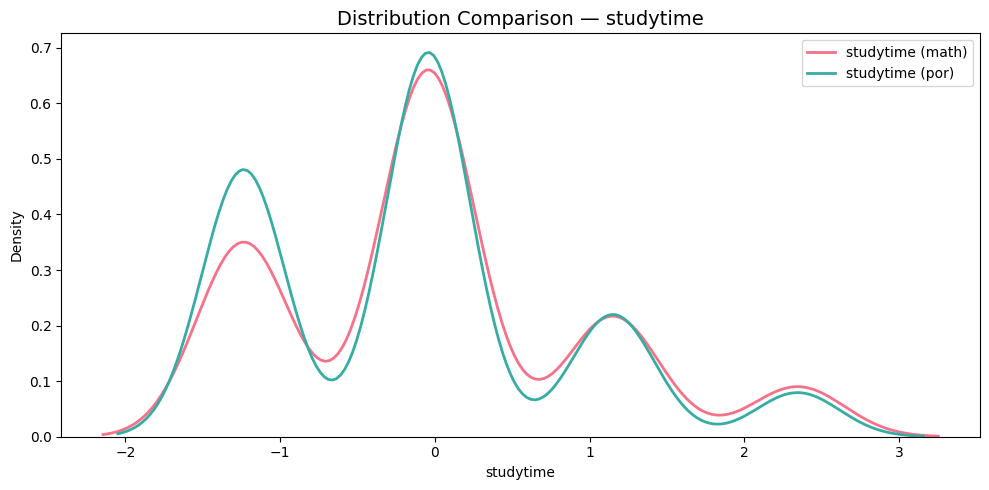

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


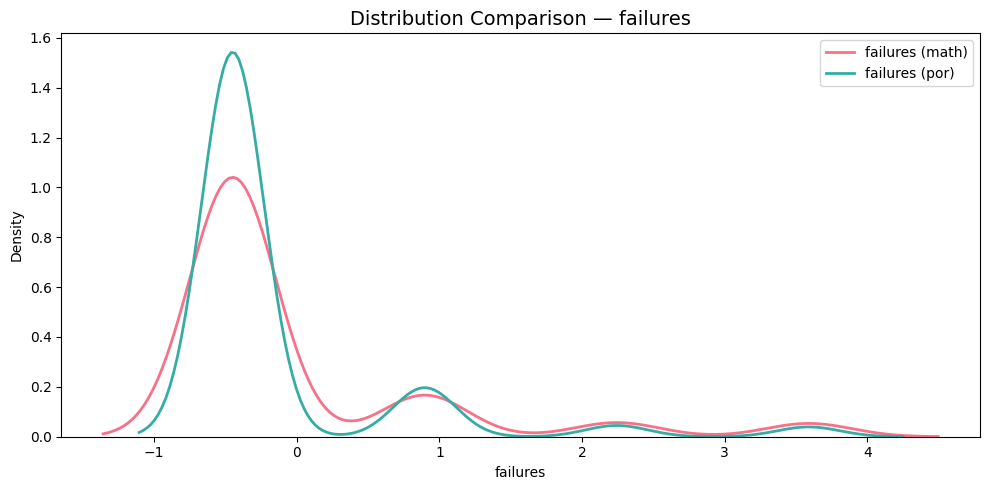

In [38]:
important_cols = ["G1", "G2", "G3", "absences", "studytime", "failures"]  # key features

for col in important_cols:  # iterate features

    plt.figure(figsize=(10, 5))  # figure per feature

    colors = sns.color_palette("husl", 2)  # two-color palette

    sns.kdeplot(
        mat[col], 
        label=f"{col} (math)",
        color=colors[0],
        linewidth=2
    )  # KDE for math

    sns.kdeplot(
        por[col],
        label=f"{col} (por)",
        color=colors[1],
        linewidth=2
    )  # KDE for Portuguese

    plt.title(f"Distribution Comparison — {col}", fontsize=14)  # plot title
    plt.legend()  # legend
    plt.tight_layout()  # layout

    plot_utils.save_all_figs(f"Distribution Comparison — {col}", "Processed")  # save figure
    plt.show()  # display